In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src')
sys.path.append('../../common/src')

In [2]:
import os
from pathlib import Path


MODEL_NAME = "Qwen/Qwen3-0.6B"

DATA_PATHS = {
    "qwen3.0.6b_honest": 
        os.path.join(Path.home(), 'projects/gonka_2stage_val/gonka/mlnode/packages/benchmarks/data/experiments/inference_fraud_hack/validation_results.jsonl'),
    "qwen3.0.6b_fraud": 
        os.path.join(Path.home(), 'projects/gonka_2stage_val/gonka/mlnode/packages/benchmarks/data/experiments/inference_fraud/validation_results.jsonl'),
    
    
}

from validation.data import (
    load_from_jsonl,
)

from validation.utils import distance2
from validation import stats

In [3]:
import matplotlib.pyplot as plt


def process_data(items):
    distances = [
        distance2(item.inference_result, item.validation_result)
        for item in items
    ]


    top_k_matches_ratios = [d[1] for d in distances]
    distances = [d[0] for d in distances]


    def clean_data(items, distances, top_k_matches_ratios):
        """
        Fix case when tokens sequences don't match
        """
        original_len = len(items)
        drop_items = []
        for item, d in zip(items, distances):
            if d == -1:
                drop_items.append(item)
            
        items = [item for item in items if item not in drop_items]
        distances = [distance for distance in distances if distance != -1]
        top_k_matches_ratios = [ratio for ratio in top_k_matches_ratios if ratio != -1]
        print(f"Dropped {len(drop_items)} / {original_len} items")

        return items, distances, top_k_matches_ratios


    items, distances, top_k_matches_ratios = clean_data(items, distances, top_k_matches_ratios)
    return items, distances, top_k_matches_ratios



def analyze(distances, top_k_matches_ratios):
    stats.describe_data(distances, name="distances")
    stats.describe_data(top_k_matches_ratios, name="top_k_matches_ratios")
    best_fit, fit_results = stats.select_best_fit(distances)
    stats.plot_real_vs_fitted(distances, dist_name=best_fit.dist_name, bins=250)

    return best_fit, fit_results


def plot_distances_and_matches(items, distances, top_k_matches_ratios, title_prefix=""):
    """
    Plots two scatter plots side by side:
      1) Distances vs. # of tokens
      2) Top-K Matches Ratios vs. # of tokens
    """
    n_tokens = [len(item.inference_result.results) for item in items]
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(n_tokens, distances, alpha=0.3)
    plt.xlabel("Number of tokens")
    plt.ylabel("Distance")
    plt.title(f"{title_prefix} Distance vs. #tokens")

    plt.subplot(1, 2, 2)
    plt.scatter(n_tokens, top_k_matches_ratios, alpha=0.3, color="orange")
    plt.xlabel("Number of tokens")
    plt.ylabel("Top-K Matches Ratio")
    plt.title(f"{title_prefix} Top-K Matches Ratio vs. #tokens")
    
    plt.tight_layout()
    plt.show()





################################################################################
Analyzing qwen3.0.6b_honest : /home/irene/projects/gonka_2stage_val/gonka/mlnode/packages/benchmarks/data/experiments/inference_fraud_hack/validation_results.jsonl
Dropped 0 / 100 items


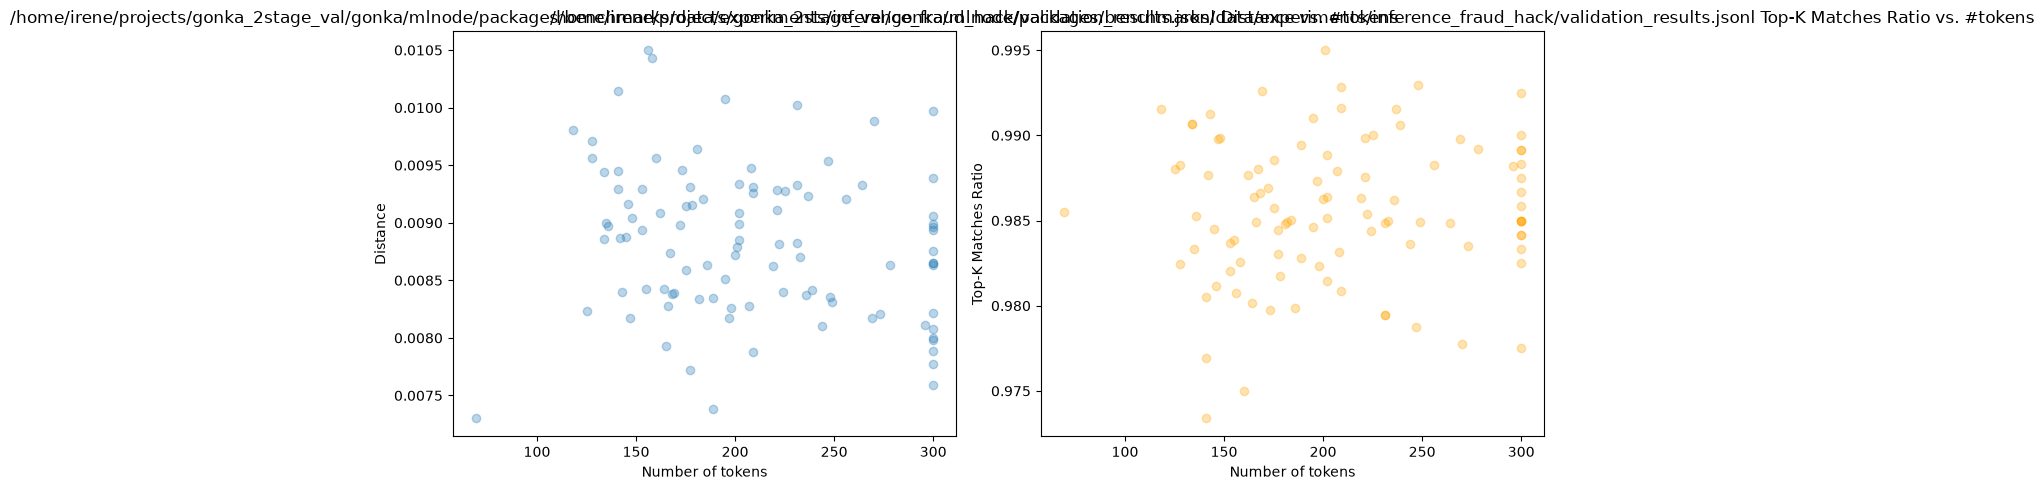


--- DISTANCES DESCRIPTIVE STATISTICS ---
Count: 100
Min:   0.0073
Max:   0.0105
Mean:  0.0088
Std:   0.0007
Quartiles:
0.25    0.008354
0.50    0.008854
0.75    0.009289
dtype: float64

--- TOP_K_MATCHES_RATIOS DESCRIPTIVE STATISTICS ---
Count: 100
Min:   0.9734
Max:   0.9950
Mean:  0.9856
Std:   0.0042
Quartiles:
0.25    0.983293
0.50    0.985221
0.75    0.988393
dtype: float64
################################################################################
Fitting normal...
Fitted Normal Params: mu=0.0088, sigma=0.0006
KS test: statistic=0.5029, p-value=0.0000
Fitting gamma...
Fitted Gamma Params: shape=186.1552, loc=0.0000, scale=0.0000
KS test: statistic=0.0712, p-value=0.6647
Fitting lognorm...
Fitted Lognormal Params: shape=0.0734, loc=0.0000, scale=0.0088
KS test: statistic=0.0686, p-value=0.7084
Fitting beta...
Fitted Beta Params: alpha=184.5137, beta=20703.2647, loc=0.0000, scale=1.0000
KS test: statistic=0.0712, p-value=0.6640
################################################

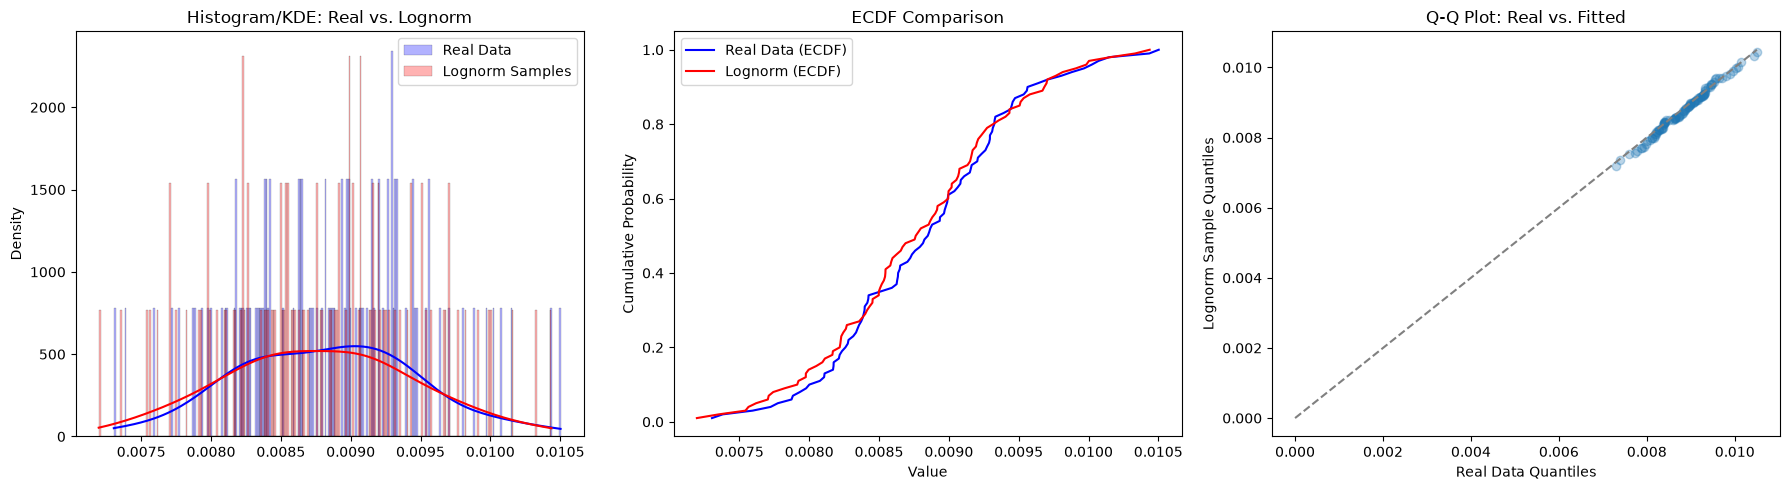




################################################################################
Analyzing qwen3.0.6b_fraud : /home/irene/projects/gonka_2stage_val/gonka/mlnode/packages/benchmarks/data/experiments/inference_fraud/validation_results.jsonl
Dropped 0 / 100 items


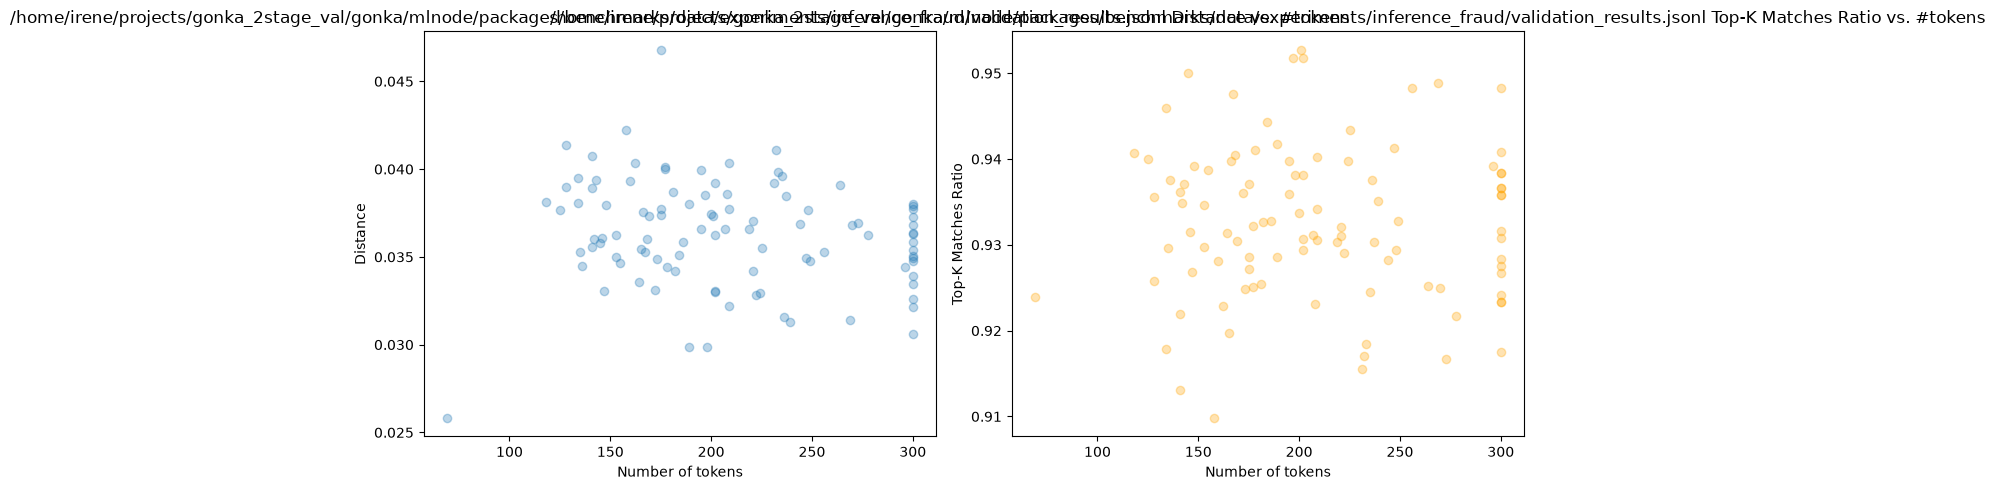


--- DISTANCES DESCRIPTIVE STATISTICS ---
Count: 100
Min:   0.0258
Max:   0.0468
Mean:  0.0363
Std:   0.0030
Quartiles:
0.25    0.034716
0.50    0.036343
0.75    0.038068
dtype: float64

--- TOP_K_MATCHES_RATIOS DESCRIPTIVE STATISTICS ---
Count: 100
Min:   0.9098
Max:   0.9527
Mean:  0.9326
Std:   0.0089
Quartiles:
0.25    0.926820
0.50    0.932165
0.75    0.938427
dtype: float64
################################################################################
Fitting normal...
Fitted Normal Params: mu=0.0363, sigma=0.0030
KS test: statistic=0.5103, p-value=0.0000
Fitting gamma...
Fitted Gamma Params: shape=141.2152, loc=0.0000, scale=0.0003
KS test: statistic=0.0595, p-value=0.8503
Fitting lognorm...
Fitted Lognormal Params: shape=0.0849, loc=0.0000, scale=0.0362
KS test: statistic=0.0641, p-value=0.7815
Fitting beta...
Fitted Beta Params: alpha=136.2164, beta=3613.6122, loc=0.0000, scale=1.0000
KS test: statistic=0.0592, p-value=0.8543
#################################################

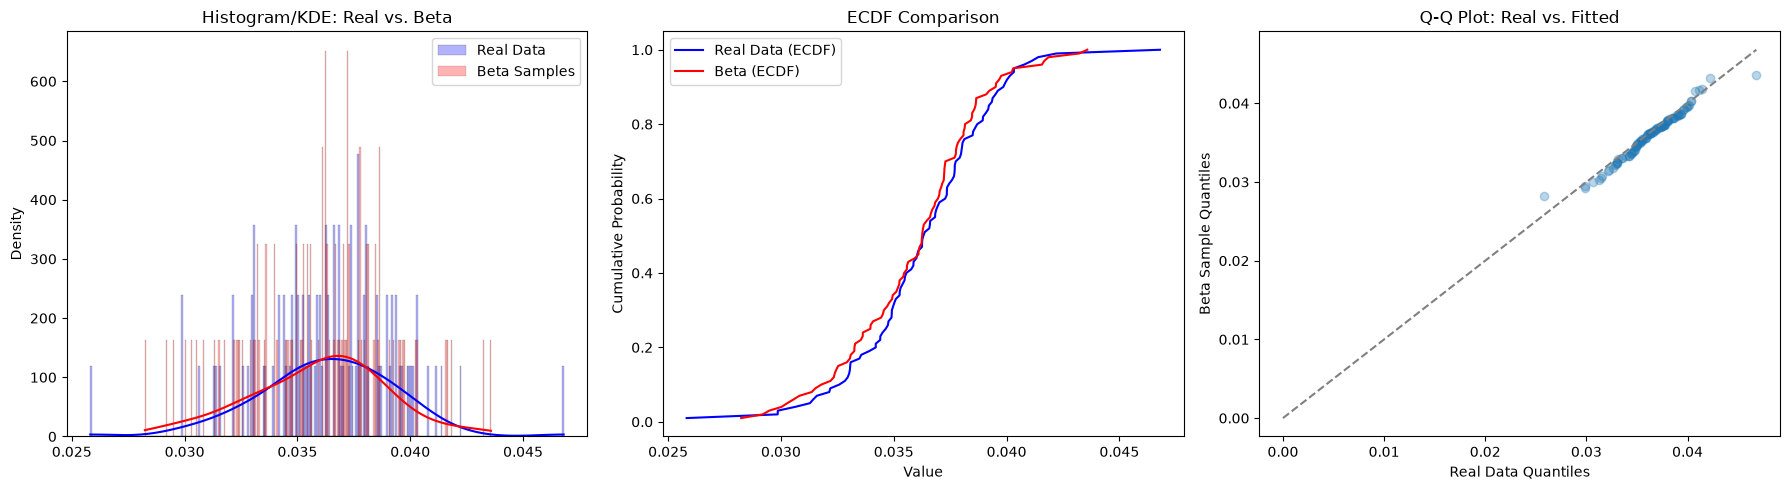

In [4]:
data_path_to_fit = {}
data_path_to_distances = {}

for name, data_path in DATA_PATHS.items():
    print("\n\n")
    print(80*"#")
    print(f"Analyzing {name} : {data_path}")
    items = load_from_jsonl(data_path, n=100000)
    items, distances, top_k_matches_ratios = process_data(items)
    plot_distances_and_matches(items, distances, top_k_matches_ratios, data_path)
    best_fit, fit_results = analyze(distances, top_k_matches_ratios)
    data_path_to_fit[data_path] = best_fit
    data_path_to_distances[data_path] = distances

In [5]:
def classify_data(distances, lower_bound, upper_bound):
    classifications = []
    for d in distances:
        if d < lower_bound:
            classifications.append('accepted')
        elif d > upper_bound:
            classifications.append('fraud')
        else:
            classifications.append('questionable')
    return classifications

Searching optimal bounds: 100%|██████████| 40/40 [00:00<00:00, 22011.57it/s]


Optimal Lower Bound: 0.011304
Optimal Upper Bound: 0.012304
Best F1-Score: 1.0000
Classification results for fraud data:
Accepted: 0, Questionable: 0, Fraud: 100
Classification results for honest data:
Accepted: 100, Questionable: 0, Fraud: 0


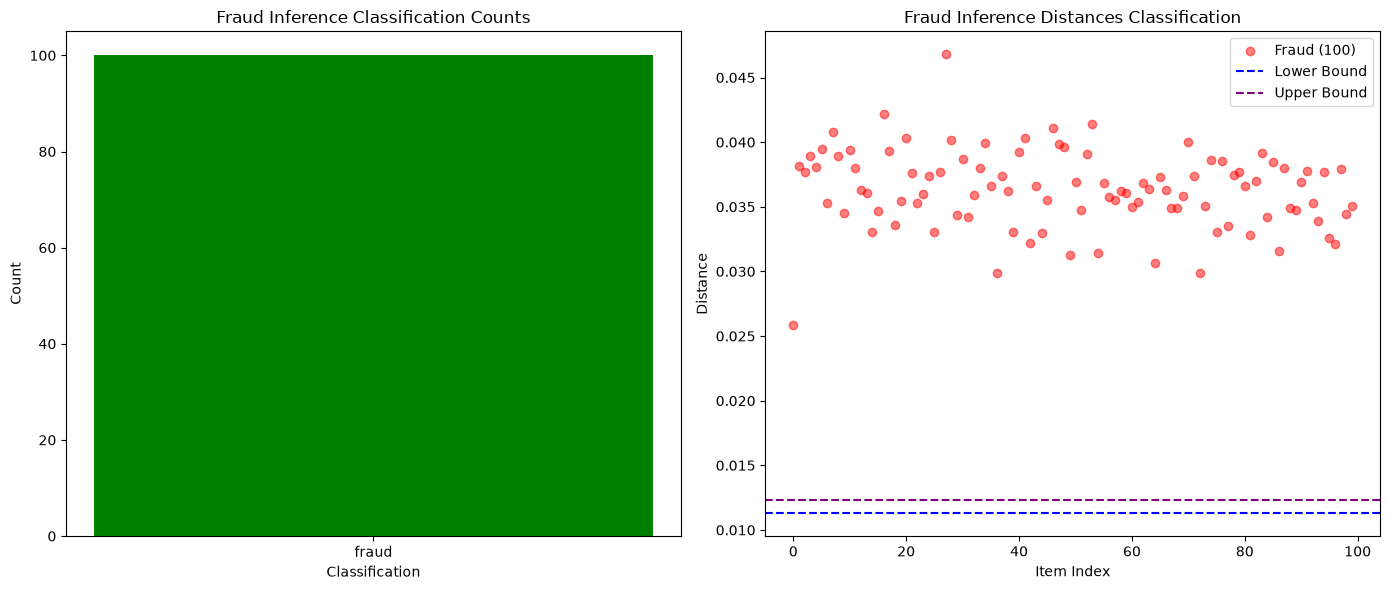

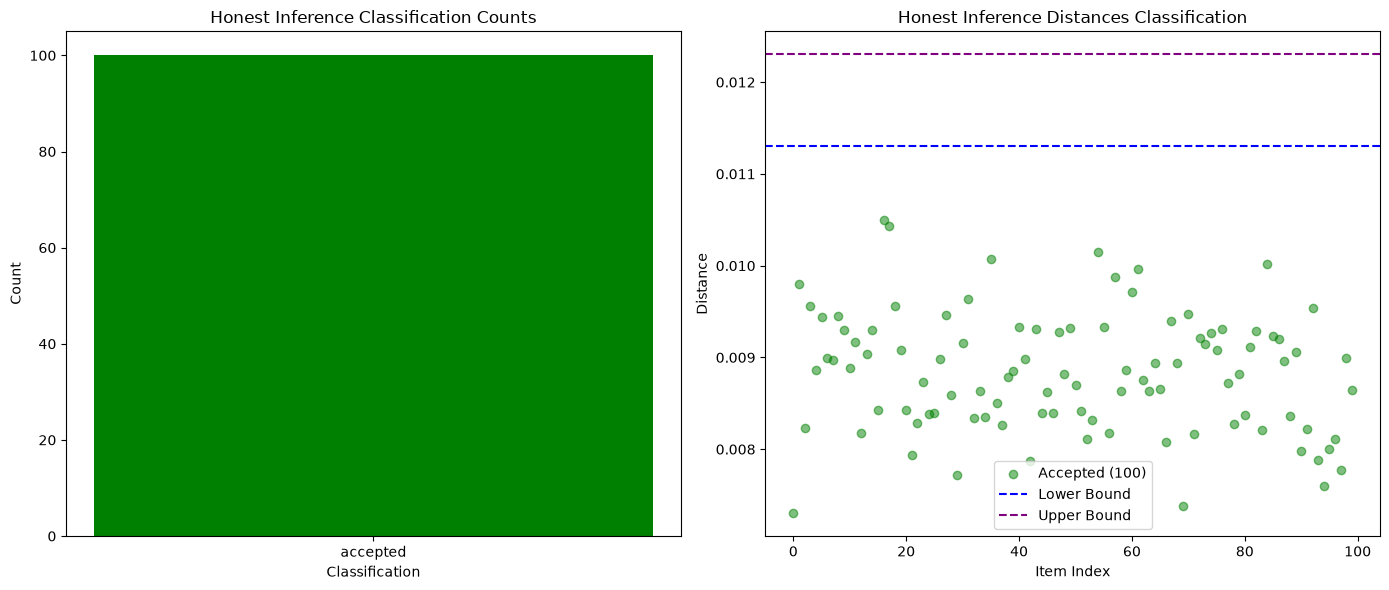

In [6]:
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from joblib import Parallel, delayed

def evaluate_bound(lower, upper_candidates, distances_val, distances_quant):
    if np.any(distances_val > lower):
        return None

    all_distances = np.concatenate([distances_val, distances_quant])
    labels_true = np.array([0] * len(distances_val) + [1] * len(distances_quant))

    best_f1 = -1
    optimal_upper = None
    for upper in upper_candidates:
        labels_pred = np.where(all_distances < lower, 0, 1)
        labels_pred[(all_distances >= lower) & (all_distances <= upper)] = 1
        current_f1 = f1_score(labels_true, labels_pred)
        if current_f1 > best_f1:
            best_f1 = current_f1
            optimal_upper = upper
    return lower, optimal_upper, best_f1


def find_optimal_bounds_parallel(distances_val, distances_quant, step=0.0001, n_jobs=-1):
    all_distances = np.concatenate([distances_val, distances_quant])
    min_dist, max_dist = all_distances.min(), all_distances.max()
    search_space = np.arange(min_dist, max_dist, step)

    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_bound)(
            lower,
            search_space[search_space > lower],
            distances_val,
            distances_quant
        )
        for lower in tqdm(search_space, desc="Searching optimal bounds")
    )

    # Remove None results that violate the constraint
    results = [r for r in results if r is not None]

    if not results:
        raise ValueError("No valid bounds found under the constraint that no distances_val exceed the lower bound.")

    optimal_lower, optimal_upper, best_f1 = max(results, key=lambda x: x[2])

    print(f"Optimal Lower Bound: {optimal_lower:.6f}")
    print(f"Optimal Upper Bound: {optimal_upper:.6f}")
    print(f"Best F1-Score: {best_f1:.4f}")

    return optimal_lower, optimal_upper


def plot_classification_results(distances, classifications, lower_bound, upper_bound, title_prefix=""):
    classification_counts = Counter(classifications)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.bar(classification_counts.keys(), classification_counts.values(), color=['green', 'orange', 'red'])
    plt.title(f"{title_prefix} Classification Counts")
    plt.xlabel("Classification")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    color_map = {'accepted': 'green', 'questionable': 'orange', 'fraud': 'red'}
    for classification in classification_counts:
        idxs = [i for i, c in enumerate(classifications) if c == classification]
        plt.scatter(
            idxs, [distances[i] for i in idxs],
            c=color_map[classification], alpha=0.5,
            label=f"{classification.capitalize()} ({classification_counts[classification]})"
        )

    plt.axhline(lower_bound, color='blue', linestyle='--', label='Lower Bound')
    plt.axhline(upper_bound, color='purple', linestyle='--', label='Upper Bound')
    plt.title(f"{title_prefix} Distances Classification")
    plt.xlabel("Item Index")
    plt.ylabel("Distance")
    plt.legend()

    plt.tight_layout()
    plt.show()


distances_honest = data_path_to_distances[os.path.join(Path.home(), DATA_PATHS["qwen3.0.6b_honest"])]
distances_fraud = data_path_to_distances[os.path.join(Path.home(), DATA_PATHS["qwen3.0.6b_fraud"])]

optimal_lower, optimal_upper = find_optimal_bounds_parallel(distances_honest, distances_fraud, n_jobs=64, step=0.001)

classifications_quant = classify_data(distances_fraud, optimal_lower, optimal_upper)
print("Classification results for fraud data:")
accepted_count = classifications_quant.count('accepted')
questionable_count = classifications_quant.count('questionable')
fraud_count = classifications_quant.count('fraud')
print(f"Accepted: {accepted_count}, Questionable: {questionable_count}, Fraud: {fraud_count}")

classifications_val = classify_data(distances_honest, optimal_lower, optimal_upper)
print("Classification results for honest data:")
accepted_count = classifications_val.count('accepted')
questionable_count = classifications_val.count('questionable')
fraud_count = classifications_val.count('fraud')
print(f"Accepted: {accepted_count}, Questionable: {questionable_count}, Fraud: {fraud_count}")

plot_classification_results(
    distances_fraud, classifications_quant, optimal_lower, optimal_upper, title_prefix="Fraud Inference"
)

plot_classification_results(
    distances_honest, classifications_val, optimal_lower, optimal_upper, title_prefix="Honest Inference"
)